In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [2]:
np.random.seed(42)

In [3]:
hierarchy = {
    'North': {
        'Category_A': {'SKU_A1': 500, 'SKU_A2': 300, 'SKU_A3': 200},
        'Category_B': {'SKU_B1': 400, 'SKU_B2': 350}
    },
    'South': {
        'Category_A': {'SKU_A4': 450, 'SKU_A5': 250},
        'Category_B': {'SKU_B3': 600, 'SKU_B4': 300, 'SKU_B5': 150}
    }
}


In [4]:
dates = pd.date_range('2022-01-01', '2024-12-31', freq='MS')

records = []
for plant, categories in hierarchy.items():
    for category, skus in categories.items():
        for sku, base_demand in skus.items():
            for date in dates:
                month = date.month
                # Seasonality: peak in summer (Jun-Aug) and year-end (Nov-Dec)
                seasonal = 1.0 + 0.2 * np.sin(2 * np.pi * (month - 4) / 12)
                if month in [11, 12]:
                    seasonal += 0.15
                # Trend: slight growth
                months_from_start = (date.year - 2022) * 12 + date.month
                trend = 1.0 + 0.005 * months_from_start
                # Random noise
                noise = np.random.normal(1.0, 0.10)
                demand = int(base_demand * seasonal * trend * noise)
                demand = max(50, demand)
                records.append({
                    'Date': date,
                    'Plant': plant,
                    'Category': category,
                    'SKU': sku,
                    'Demand': demand
                })

df = pd.DataFrame(records)

print(f"Dataset: {len(df)} rows")
print(f"  SKUs: {df['SKU'].nunique()}")
print(f"  Categories: {df['Category'].nunique()}")
print(f"  Plants: {df['Plant'].nunique()}")
print(f"  Months: {df['Date'].nunique()}")
print(f"\nHierarchy structure:")
for plant, categories in hierarchy.items():
    print(f"  Plant {plant}:")
    for cat, skus in categories.items():
        print(f"    {cat}: {list(skus.keys())}")

Dataset: 360 rows
  SKUs: 10
  Categories: 2
  Plants: 2
  Months: 36

Hierarchy structure:
  Plant North:
    Category_A: ['SKU_A1', 'SKU_A2', 'SKU_A3']
    Category_B: ['SKU_B1', 'SKU_B2']
  Plant South:
    Category_A: ['SKU_A4', 'SKU_A5']
    Category_B: ['SKU_B3', 'SKU_B4', 'SKU_B5']


In [5]:
total = df.groupby('Date')['Demand'].sum().reset_index()
total.columns = ['Date', 'Total']

# Level 1: By Plant
by_plant = df.groupby(['Date', 'Plant'])['Demand'].sum().reset_index()

# Level 2: By Plant + Category
by_cat = df.groupby(['Date', 'Plant', 'Category'])['Demand'].sum().reset_index()

# Level 3: By SKU (bottom level)
by_sku = df.groupby(['Date', 'SKU'])['Demand'].sum().reset_index()

print("\nAggregation levels:")
print(f"  Level 0 (Total):         1 series")
print(f"  Level 1 (Plant):         {by_plant['Plant'].nunique()} series")
print(f"  Level 2 (Plant x Cat):   {by_cat.groupby(['Plant','Category']).ngroups} series")
print(f"  Level 3 (SKU):           {by_sku['SKU'].nunique()} series")
print(f"  Total series to forecast: {1 + 2 + 4 + 10} = 17 series")

# COHERENCE CHECK: Do parts sum to whole?
sample_date = dates[0]
total_demand = total[total['Date'] == sample_date]['Total'].values[0]
plant_sum = by_plant[by_plant['Date'] == sample_date]['Demand'].sum()
sku_sum = by_sku[by_sku['Date'] == sample_date]['Demand'].sum()

print(f"\nCoherence check for {sample_date.strftime('%Y-%m')}:")
print(f"  Total level:   {total_demand:,}")
print(f"  Plant sum:     {plant_sum:,}")
print(f"  SKU sum:       {sku_sum:,}")
print(f"  All equal? {'YES - hierarchy is coherent' if total_demand == plant_sum == sku_sum else 'NO - mismatch!'}")


Aggregation levels:
  Level 0 (Total):         1 series
  Level 1 (Plant):         2 series
  Level 2 (Plant x Cat):   4 series
  Level 3 (SKU):           10 series
  Total series to forecast: 17 = 17 series

Coherence check for 2022-01:
  Total level:   2,952
  Plant sum:     2,952
  SKU sum:       2,952
  All equal? YES - hierarchy is coherent


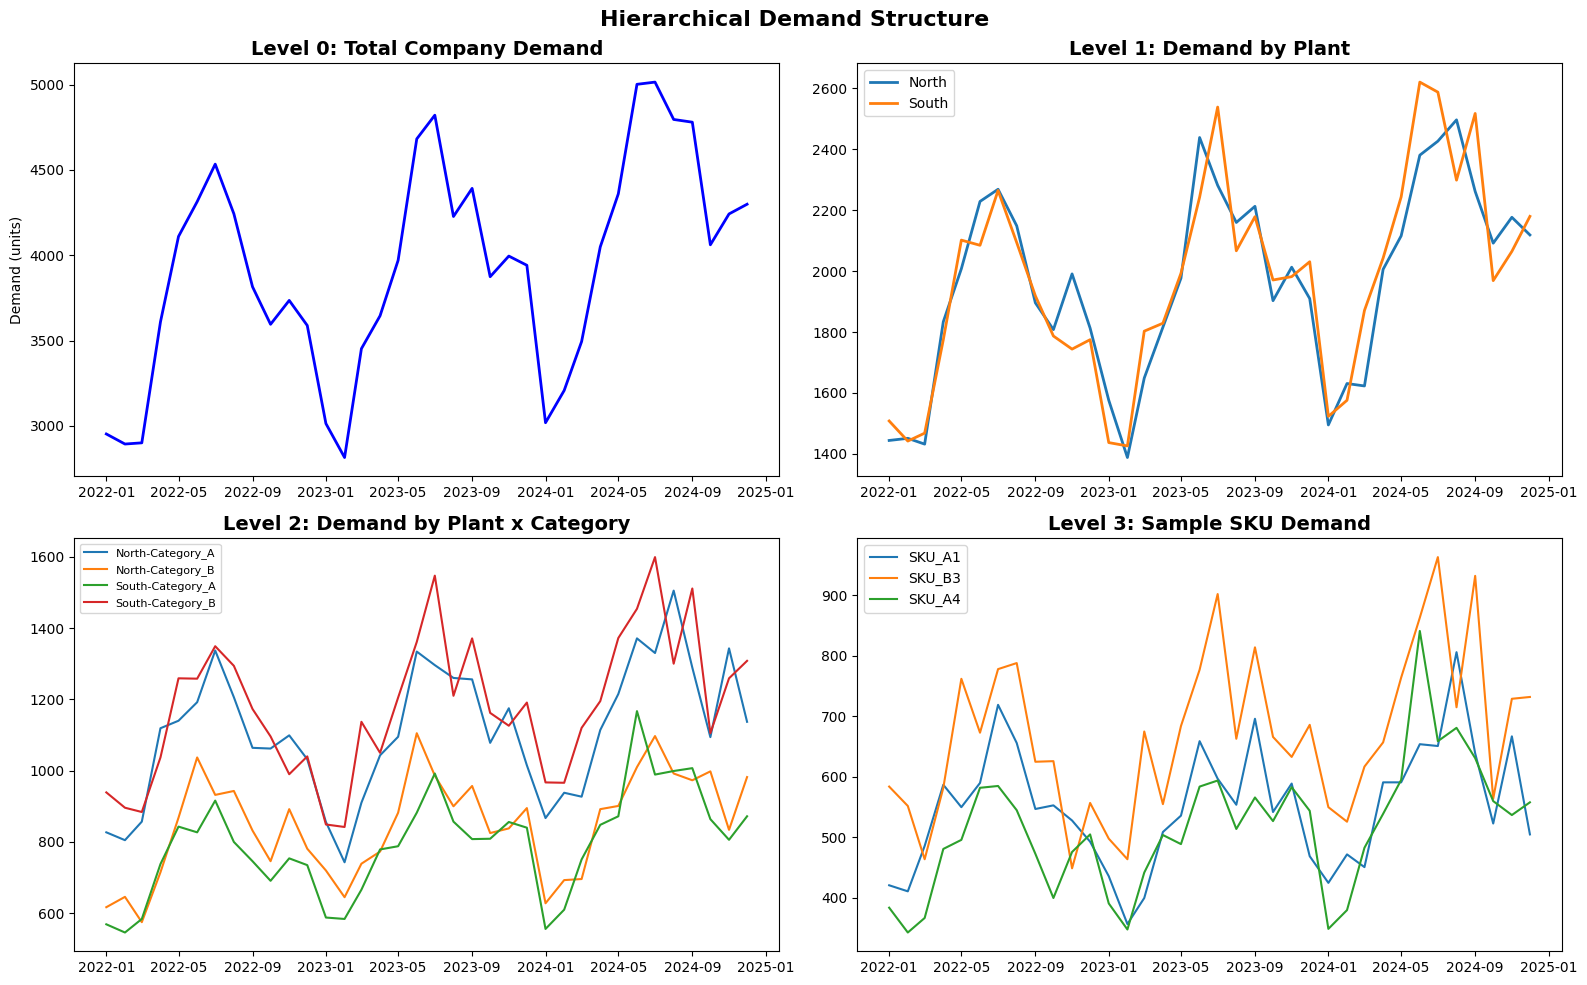

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Total
axes[0,0].plot(total['Date'], total['Total'], 'b-', linewidth=2)
axes[0,0].set_title('Level 0: Total Company Demand', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Demand (units)')

# By Plant
for plant in ['North', 'South']:
    data = by_plant[by_plant['Plant'] == plant]
    axes[0,1].plot(data['Date'], data['Demand'], linewidth=2, label=plant)
axes[0,1].set_title('Level 1: Demand by Plant', fontsize=14, fontweight='bold')
axes[0,1].legend()

# By Category (per plant)
for _, grp in by_cat.groupby(['Plant', 'Category']):
    label = f"{grp['Plant'].iloc[0]}-{grp['Category'].iloc[0]}"
    axes[1,0].plot(grp['Date'], grp['Demand'], linewidth=1.5, label=label)
axes[1,0].set_title('Level 2: Demand by Plant x Category', fontsize=14, fontweight='bold')
axes[1,0].legend(fontsize=8)

# Sample SKUs
for sku in ['SKU_A1', 'SKU_B3', 'SKU_A4']:
    data = by_sku[by_sku['SKU'] == sku]
    axes[1,1].plot(data['Date'], data['Demand'], linewidth=1.5, label=sku)
axes[1,1].set_title('Level 3: Sample SKU Demand', fontsize=14, fontweight='bold')
axes[1,1].legend()

plt.suptitle('Hierarchical Demand Structure', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_hierarchy_structure.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
train_end = '2024-06-01'
test_start = '2024-07-01'

def simple_forecast(series, n_forecast=6):
    """Simple exponential smoothing forecast."""
    alpha = 0.3
    level = series.iloc[0]
    for val in series:
        level = alpha * val + (1 - alpha) * level
    # Forecast: last level repeated (flat forecast) + seasonal adjustment
    last_6 = series.tail(12).values[:6]  # Same months last year
    current_level = level
    last_year_avg = series.tail(12).mean()
    seasonal_indices = last_6 / last_year_avg if last_year_avg > 0 else np.ones(6)
    forecasts = current_level * seasonal_indices
    return forecasts.clip(50, None)

In [8]:
print("=" * 60)
print("BOTTOM-UP APPROACH")
print("=" * 60)
print("""
Strategy: Forecast each SKU independently, then SUM UP.
  Step 1: Forecast SKU_A1, SKU_A2, ..., SKU_B5 (10 forecasts)
  Step 2: Category_A_North = SKU_A1 + SKU_A2 + SKU_A3
  Step 3: Plant_North = Category_A_North + Category_B_North
  Step 4: Total = Plant_North + Plant_South

ADVANTAGE: Most granular. Captures SKU-level patterns.
DISADVANTAGE: Noisy at SKU level. Errors compound when summing.
             SKU forecasts may miss category-level trends.
""")

# Forecast each SKU
sku_forecasts_bu = {}
sku_actuals = {}

for sku in df['SKU'].unique():
    sku_data = df[df['SKU'] == sku].sort_values('Date')
    train = sku_data[sku_data['Date'] <= train_end]['Demand']
    test = sku_data[sku_data['Date'] >= test_start]['Demand']
    
    fc = simple_forecast(train)
    sku_forecasts_bu[sku] = fc[:len(test)]
    sku_actuals[sku] = test.values

# Aggregate forecasts bottom-up
test_dates = df[df['Date'] >= test_start]['Date'].unique()[:6]

# Build bottom-up aggregations
bu_results = []
for i, date in enumerate(test_dates):
    for plant, categories in hierarchy.items():
        for category, skus in categories.items():
            for sku in skus:
                fc = sku_forecasts_bu[sku][i] if i < len(sku_forecasts_bu[sku]) else 0
                ac = sku_actuals[sku][i] if i < len(sku_actuals[sku]) else 0
                bu_results.append({
                    'Date': date, 'Plant': plant, 'Category': category,
                    'SKU': sku, 'Forecast_BU': fc, 'Actual': ac
                })

bu_df = pd.DataFrame(bu_results)

# Bottom-up aggregation
bu_total = bu_df.groupby('Date').agg(
    Forecast_BU=('Forecast_BU', 'sum'), Actual=('Actual', 'sum')
).reset_index()
bu_total['MAPE'] = abs(bu_total['Forecast_BU'] - bu_total['Actual']) / bu_total['Actual'] * 100

print("Bottom-Up: Total Level Accuracy")
print(f"  Average MAPE: {bu_total['MAPE'].mean():.1f}%")


# ---- STEP 3.2: Top-Down Approach ----

print("\n" + "=" * 60)
print("TOP-DOWN APPROACH")
print("=" * 60)
print("""
Strategy: Forecast at TOTAL level, then ALLOCATE down using proportions.
  Step 1: Forecast Total Company demand (1 forecast)
  Step 2: Historical proportion: Plant North = 48%, South = 52%
  Step 3: Plant_North forecast = Total forecast x 0.48
  Step 4: Continue allocating down to Category and SKU

ADVANTAGE: Stable at top level (less noise). Captures macro trends.
DISADVANTAGE: Assumes proportions are stable over time.
             Misses SKU-level shifts (e.g., one SKU growing fast).
""")

# Forecast total
total_train = total[total['Date'] <= train_end]['Total']
total_fc = simple_forecast(total_train)

# Calculate historical proportions
prop_data = df[df['Date'] <= train_end]

# Plant proportions
plant_props = prop_data.groupby('Plant')['Demand'].sum()
plant_props = plant_props / plant_props.sum()
print(f"Historical plant proportions: {dict(plant_props.round(3))}")

# Category proportions within each plant
cat_props = {}
for plant in hierarchy:
    plant_data = prop_data[prop_data['Plant'] == plant]
    cat_totals = plant_data.groupby('Category')['Demand'].sum()
    cat_props[plant] = (cat_totals / cat_totals.sum()).to_dict()
    print(f"  {plant} category proportions: {dict(pd.Series(cat_props[plant]).round(3))}")

# SKU proportions within each plant-category
sku_props = {}
for plant in hierarchy:
    for cat in hierarchy[plant]:
        key = f"{plant}_{cat}"
        pc_data = prop_data[(prop_data['Plant'] == plant) & (prop_data['Category'] == cat)]
        sku_totals = pc_data.groupby('SKU')['Demand'].sum()
        sku_props[key] = (sku_totals / sku_totals.sum()).to_dict()

# Allocate top-down
td_results = []
for i, date in enumerate(test_dates):
    total_forecast = total_fc[i] if i < len(total_fc) else total_fc[-1]
    
    for plant in hierarchy:
        plant_forecast = total_forecast * plant_props[plant]
        
        for cat in hierarchy[plant]:
            cat_forecast = plant_forecast * cat_props[plant][cat]
            
            for sku in hierarchy[plant][cat]:
                key = f"{plant}_{cat}"
                sku_forecast = cat_forecast * sku_props[key].get(sku, 0)
                actual = sku_actuals[sku][i] if i < len(sku_actuals[sku]) else 0
                
                td_results.append({
                    'Date': date, 'Plant': plant, 'Category': cat,
                    'SKU': sku, 'Forecast_TD': sku_forecast, 'Actual': actual
                })

td_df = pd.DataFrame(td_results)

td_total = td_df.groupby('Date').agg(
    Forecast_TD=('Forecast_TD', 'sum'), Actual=('Actual', 'sum')
).reset_index()
td_total['MAPE'] = abs(td_total['Forecast_TD'] - td_total['Actual']) / td_total['Actual'] * 100

print(f"\nTop-Down: Total Level Accuracy")
print(f"  Average MAPE: {td_total['MAPE'].mean():.1f}%")

BOTTOM-UP APPROACH

Strategy: Forecast each SKU independently, then SUM UP.
  Step 1: Forecast SKU_A1, SKU_A2, ..., SKU_B5 (10 forecasts)
  Step 2: Category_A_North = SKU_A1 + SKU_A2 + SKU_A3
  Step 3: Plant_North = Category_A_North + Category_B_North
  Step 4: Total = Plant_North + Plant_South

ADVANTAGE: Most granular. Captures SKU-level patterns.
DISADVANTAGE: Noisy at SKU level. Errors compound when summing.
             SKU forecasts may miss category-level trends.

Bottom-Up: Total Level Accuracy
  Average MAPE: 2.8%

TOP-DOWN APPROACH

Strategy: Forecast at TOTAL level, then ALLOCATE down using proportions.
  Step 1: Forecast Total Company demand (1 forecast)
  Step 2: Historical proportion: Plant North = 48%, South = 52%
  Step 3: Plant_North forecast = Total forecast x 0.48
  Step 4: Continue allocating down to Category and SKU

ADVANTAGE: Stable at top level (less noise). Captures macro trends.
DISADVANTAGE: Assumes proportions are stable over time.
             Misses SKU-le

In [9]:
print("\n" + "=" * 60)
print("MIDDLE-OUT APPROACH")
print("=" * 60)
print("""
Strategy: Forecast at MIDDLE level (Category), then:
  - SUM UP to Plant and Total (bottom-up from category)
  - ALLOCATE DOWN to SKU using proportions (top-down from category)

ADVANTAGE: Best of both worlds. Category level is stable enough
           to forecast well, but granular enough to capture trends.
DISADVANTAGE: Requires choosing the right "middle" level.

THIS IS THE MOST COMMON APPROACH IN INDUSTRY.
At HPCL, I would forecast at the product-category level and
allocate to SKUs using historical proportions.
""")

# Forecast each Plant-Category combination
mo_cat_forecasts = {}
for plant in hierarchy:
    for cat in hierarchy[plant]:
        cat_data = df[(df['Plant'] == plant) & (df['Category'] == cat)]
        cat_ts = cat_data.groupby('Date')['Demand'].sum().sort_index()
        train = cat_ts[cat_ts.index <= train_end]
        mo_cat_forecasts[f"{plant}_{cat}"] = simple_forecast(train)

# Allocate down to SKU and sum up to Total
mo_results = []
for i, date in enumerate(test_dates):
    for plant in hierarchy:
        for cat in hierarchy[plant]:
            key = f"{plant}_{cat}"
            cat_fc = mo_cat_forecasts[key][i] if i < len(mo_cat_forecasts[key]) else 0
            
            for sku in hierarchy[plant][cat]:
                sku_prop = sku_props[key].get(sku, 0)
                sku_fc = cat_fc * sku_prop
                actual = sku_actuals[sku][i] if i < len(sku_actuals[sku]) else 0
                
                mo_results.append({
                    'Date': date, 'Plant': plant, 'Category': cat,
                    'SKU': sku, 'Forecast_MO': sku_fc, 'Actual': actual
                })

mo_df = pd.DataFrame(mo_results)

mo_total = mo_df.groupby('Date').agg(
    Forecast_MO=('Forecast_MO', 'sum'), Actual=('Actual', 'sum')
).reset_index()
mo_total['MAPE'] = abs(mo_total['Forecast_MO'] - mo_total['Actual']) / mo_total['Actual'] * 100

print(f"Middle-Out: Total Level Accuracy")
print(f"  Average MAPE: {mo_total['MAPE'].mean():.1f}%")


MIDDLE-OUT APPROACH

Strategy: Forecast at MIDDLE level (Category), then:
  - SUM UP to Plant and Total (bottom-up from category)
  - ALLOCATE DOWN to SKU using proportions (top-down from category)

ADVANTAGE: Best of both worlds. Category level is stable enough
           to forecast well, but granular enough to capture trends.
DISADVANTAGE: Requires choosing the right "middle" level.

THIS IS THE MOST COMMON APPROACH IN INDUSTRY.
At HPCL, I would forecast at the product-category level and
allocate to SKUs using historical proportions.

Middle-Out: Total Level Accuracy
  Average MAPE: 2.9%


In [10]:
print("\n" + "=" * 60)
print("     APPROACH COMPARISON")
print("=" * 60)

# Merge all
comparison = bu_total[['Date', 'Actual']].copy()
comparison['Bottom_Up'] = bu_total['Forecast_BU']
comparison['Top_Down'] = td_total['Forecast_TD']
comparison['Middle_Out'] = mo_total['Forecast_MO']

print("\nTotal Level Forecasts vs Actuals:")
print(comparison.round(0).to_string(index=False))

# MAPE by approach at each level
def calc_mape(forecast, actual):
    return (abs(forecast - actual) / actual * 100).mean()

print(f"\nMAPE COMPARISON:")
print(f"  {'Approach':<15} {'Total':>8} {'Plant':>8} {'Category':>8} {'SKU':>8}")
print(f"  {'-'*47}")

# Total level
mape_bu_total = calc_mape(bu_total['Forecast_BU'], bu_total['Actual'])
mape_td_total = calc_mape(td_total['Forecast_TD'], td_total['Actual'])
mape_mo_total = calc_mape(mo_total['Forecast_MO'], mo_total['Actual'])

# SKU level
bu_sku_mape = bu_df.groupby('SKU').apply(lambda x: calc_mape(x['Forecast_BU'], x['Actual'])).mean()
td_sku_mape = td_df.groupby('SKU').apply(lambda x: calc_mape(x['Forecast_TD'], x['Actual'])).mean()
mo_sku_mape = mo_df.groupby('SKU').apply(lambda x: calc_mape(x['Forecast_MO'], x['Actual'])).mean()

# Plant level
bu_plant = bu_df.groupby(['Date','Plant']).agg(F=('Forecast_BU','sum'), A=('Actual','sum')).reset_index()
td_plant = td_df.groupby(['Date','Plant']).agg(F=('Forecast_TD','sum'), A=('Actual','sum')).reset_index()
mo_plant = mo_df.groupby(['Date','Plant']).agg(F=('Forecast_MO','sum'), A=('Actual','sum')).reset_index()

bu_plant_mape = calc_mape(bu_plant['F'], bu_plant['A'])
td_plant_mape = calc_mape(td_plant['F'], td_plant['A'])
mo_plant_mape = calc_mape(mo_plant['F'], mo_plant['A'])

# Category level
bu_cat = bu_df.groupby(['Date','Plant','Category']).agg(F=('Forecast_BU','sum'), A=('Actual','sum')).reset_index()
td_cat = td_df.groupby(['Date','Plant','Category']).agg(F=('Forecast_TD','sum'), A=('Actual','sum')).reset_index()
mo_cat = mo_df.groupby(['Date','Plant','Category']).agg(F=('Forecast_MO','sum'), A=('Actual','sum')).reset_index()

bu_cat_mape = calc_mape(bu_cat['F'], bu_cat['A'])
td_cat_mape = calc_mape(td_cat['F'], td_cat['A'])
mo_cat_mape = calc_mape(mo_cat['F'], mo_cat['A'])

print(f"  {'Bottom-Up':<15} {mape_bu_total:>7.1f}% {bu_plant_mape:>7.1f}% {bu_cat_mape:>7.1f}% {bu_sku_mape:>7.1f}%")
print(f"  {'Top-Down':<15} {mape_td_total:>7.1f}% {td_plant_mape:>7.1f}% {td_cat_mape:>7.1f}% {td_sku_mape:>7.1f}%")
print(f"  {'Middle-Out':<15} {mape_mo_total:>7.1f}% {mo_plant_mape:>7.1f}% {mo_cat_mape:>7.1f}% {mo_sku_mape:>7.1f}%")

print("""
EXPECTED PATTERN:
  Bottom-Up:  Best at SKU level, worst at Total (noise accumulates)
  Top-Down:   Best at Total level, worst at SKU (detail lost)
  Middle-Out: Balanced across all levels (best compromise)
""")


     APPROACH COMPARISON

Total Level Forecasts vs Actuals:
      Date  Actual  Bottom_Up  Top_Down  Middle_Out
2024-07-01    5015     5051.0    5059.0      5060.0
2024-08-01    4796     4430.0    4436.0      4435.0
2024-09-01    4780     4608.0    4609.0      4604.0
2024-10-01    4061     4066.0    4065.0      4066.0
2024-11-01    4242     4195.0    4192.0      4194.0
2024-12-01    4299     4135.0    4136.0      4137.0

MAPE COMPARISON:
  Approach           Total    Plant Category      SKU
  -----------------------------------------------
  Bottom-Up           2.8%     4.8%     6.5%     9.0%
  Top-Down            2.8%     4.2%     6.1%     7.4%
  Middle-Out          2.9%     4.8%     6.5%     8.0%

EXPECTED PATTERN:
  Bottom-Up:  Best at SKU level, worst at Total (noise accumulates)
  Top-Down:   Best at Total level, worst at SKU (detail lost)
  Middle-Out: Balanced across all levels (best compromise)



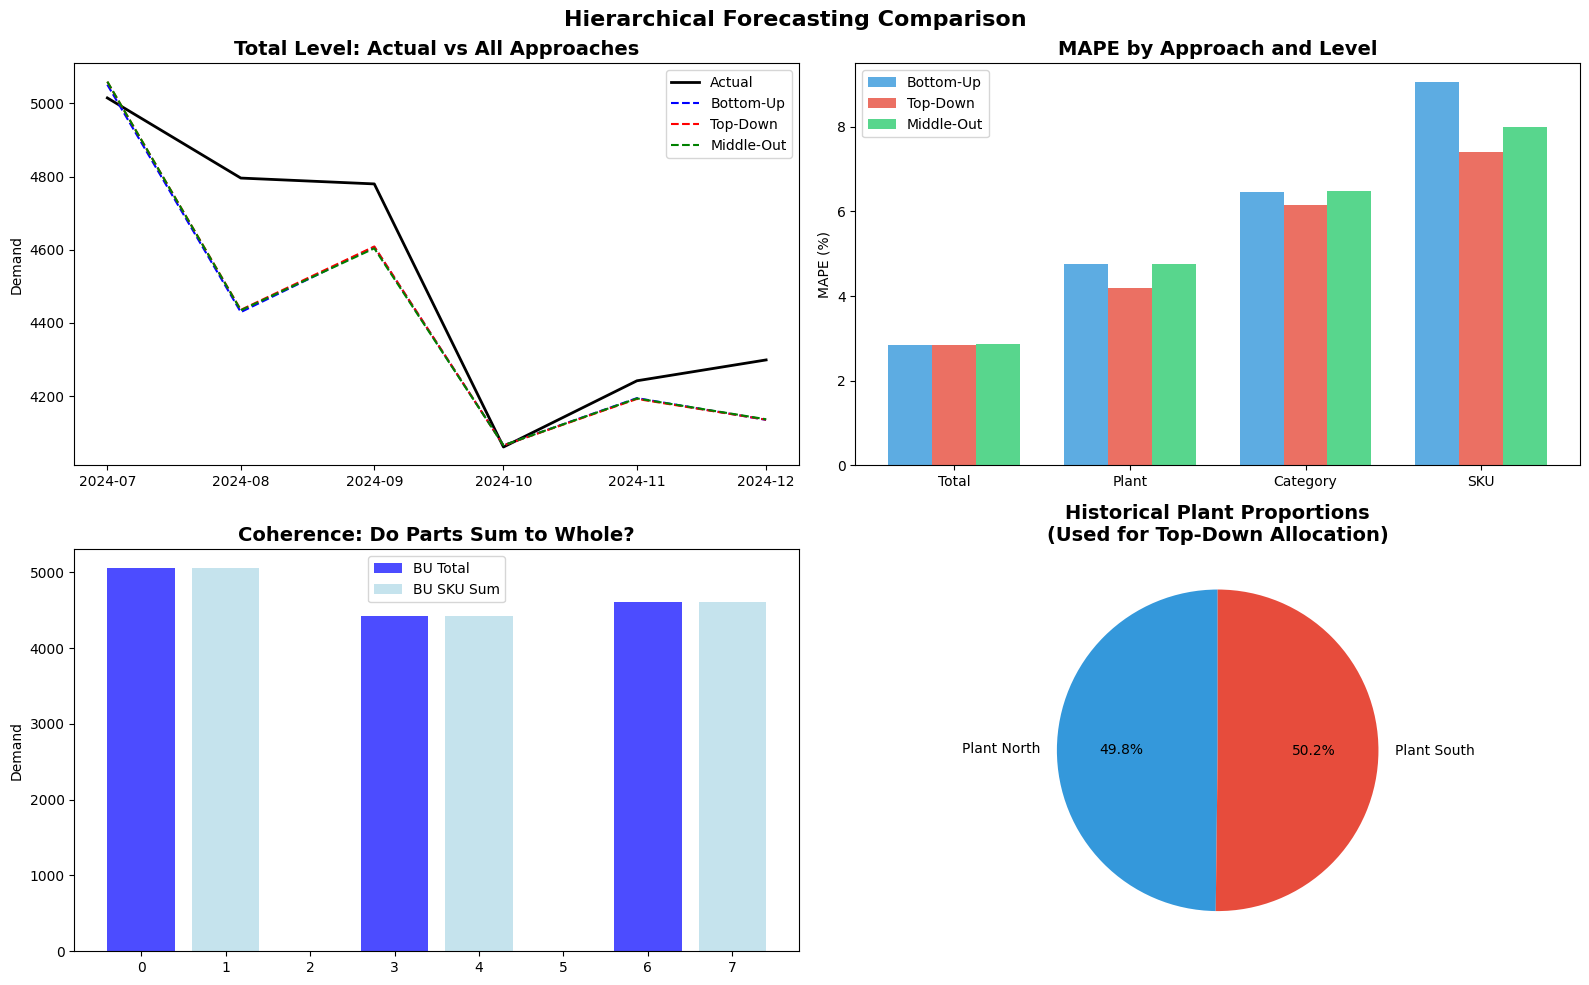

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Total level comparison
axes[0,0].plot(comparison['Date'], comparison['Actual'], 'k-', linewidth=2, label='Actual')
axes[0,0].plot(comparison['Date'], comparison['Bottom_Up'], 'b--', linewidth=1.5, label='Bottom-Up')
axes[0,0].plot(comparison['Date'], comparison['Top_Down'], 'r--', linewidth=1.5, label='Top-Down')
axes[0,0].plot(comparison['Date'], comparison['Middle_Out'], 'g--', linewidth=1.5, label='Middle-Out')
axes[0,0].set_title('Total Level: Actual vs All Approaches', fontsize=14, fontweight='bold')
axes[0,0].legend()
axes[0,0].set_ylabel('Demand')

# MAPE comparison bar chart
approaches = ['Bottom-Up', 'Top-Down', 'Middle-Out']
levels = ['Total', 'Plant', 'Category', 'SKU']
mapes = [
    [mape_bu_total, bu_plant_mape, bu_cat_mape, bu_sku_mape],
    [mape_td_total, td_plant_mape, td_cat_mape, td_sku_mape],
    [mape_mo_total, mo_plant_mape, mo_cat_mape, mo_sku_mape],
]
x = np.arange(len(levels))
width = 0.25
for i, (approach, color) in enumerate(zip(approaches, ['#3498db', '#e74c3c', '#2ecc71'])):
    axes[0,1].bar(x + i*width, mapes[i], width, label=approach, color=color, alpha=0.8)
axes[0,1].set_xticks(x + width)
axes[0,1].set_xticklabels(levels)
axes[0,1].set_title('MAPE by Approach and Level', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('MAPE (%)')
axes[0,1].legend()

# Coherence demonstration
axes[1,0].set_title('Coherence: Do Parts Sum to Whole?', fontsize=14, fontweight='bold')
for i, date in enumerate(test_dates[:3]):
    bu_sku_sum = bu_df[bu_df['Date'] == date]['Forecast_BU'].sum()
    bu_total_val = comparison[comparison['Date'] == date]['Bottom_Up'].values[0]
    axes[1,0].bar(i*3, bu_total_val, color='blue', alpha=0.7, label='BU Total' if i==0 else '')
    axes[1,0].bar(i*3+1, bu_sku_sum, color='lightblue', alpha=0.7, label='BU SKU Sum' if i==0 else '')
axes[1,0].legend()
axes[1,0].set_ylabel('Demand')

# Proportions pie chart
props_north = plant_props['North']
props_south = plant_props['South']
axes[1,1].pie([props_north, props_south], labels=['Plant North', 'Plant South'],
              autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], startangle=90)
axes[1,1].set_title('Historical Plant Proportions\n(Used for Top-Down Allocation)', fontsize=14, fontweight='bold')

plt.suptitle('Hierarchical Forecasting Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_approach_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print("""
=========================================================
OPTIMAL RECONCILIATION (MinT / OLS)
=========================================================

The three basic approaches all have limitations:
  Bottom-Up: ignores information at higher levels
  Top-Down: loses granular patterns
  Middle-Out: somewhat arbitrary choice of middle level

OPTIMAL RECONCILIATION solves this by:
  1. Forecast EVERY level independently (17 separate forecasts)
  2. Use a statistical method to COMBINE them optimally
  3. The combination MINIMIZES total forecast error
  4. The result is COHERENT (parts sum to whole)

MATH (simplified):
  Let y_hat = vector of all independent forecasts (17 values)
  Let S = summing matrix (defines how hierarchy adds up)
  
  Reconciled forecast = S x (S'WS)^-1 x S'W x y_hat
  
  Where W is a weight matrix based on forecast error variances.
  Forecasts with lower error get MORE weight.
  
  This is called MinT (Minimum Trace) reconciliation.

IN PRACTICE:
  Python library: statsforecast or hierarchicalforecast
  R library: fable / hts

  from hierarchicalforecast.methods import MinTrace
  reconciled = MinTrace(method='mint_shrink').reconcile(forecasts, S, residuals)

FOR INTERVIEWS:
  Know the concept. You don't need to implement the math.
  "I would forecast at all levels independently, then use MinT
   reconciliation to find the statistically optimal combination
   that is coherent across the hierarchy."
""")




OPTIMAL RECONCILIATION (MinT / OLS)

The three basic approaches all have limitations:
  Bottom-Up: ignores information at higher levels
  Top-Down: loses granular patterns
  Middle-Out: somewhat arbitrary choice of middle level

OPTIMAL RECONCILIATION solves this by:
  1. Forecast EVERY level independently (17 separate forecasts)
  2. Use a statistical method to COMBINE them optimally
  3. The combination MINIMIZES total forecast error
  4. The result is COHERENT (parts sum to whole)

MATH (simplified):
  Let y_hat = vector of all independent forecasts (17 values)
  Let S = summing matrix (defines how hierarchy adds up)

  Reconciled forecast = S x (S'WS)^-1 x S'W x y_hat

  Where W is a weight matrix based on forecast error variances.
  Forecasts with lower error get MORE weight.

  This is called MinT (Minimum Trace) reconciliation.

IN PRACTICE:
  Python library: statsforecast or hierarchicalforecast
  R library: fable / hts

  from hierarchicalforecast.methods import MinTrace
  re

In [13]:
print("""
=========================================================
PRACTICAL GUIDE: WHICH APPROACH TO USE?
=========================================================

SITUATION                        RECOMMENDATION
---------                        --------------
Few SKUs (<50), stable demand    Bottom-Up (manageable, granular)
Many SKUs (>500), noisy demand   Top-Down or Middle-Out (less noise)
New products (no SKU history)    Top-Down (allocate from category)
Mature products                  Bottom-Up (reliable SKU patterns)
Mixed portfolio                  Middle-Out (compromise)
Statistical rigor needed         Optimal Reconciliation (MinT)
Quick & practical                Middle-Out (most common in industry)

MY APPROACH AT HPCL:
  I used Middle-Out: forecast at product-category level (the level
  where I had the most business knowledge and data stability),
  then allocated down to SKUs using recent 3-month proportions
  (not annual proportions -- proportions shift with seasons).
  
  For financial planning: I summed up to total and compared
  against the CFO's revenue targets for alignment.
  
  Reconciliation frequency: Monthly, aligned with S&OP cycle.
""")


PRACTICAL GUIDE: WHICH APPROACH TO USE?

SITUATION                        RECOMMENDATION
---------                        --------------
Few SKUs (<50), stable demand    Bottom-Up (manageable, granular)
Many SKUs (>500), noisy demand   Top-Down or Middle-Out (less noise)
New products (no SKU history)    Top-Down (allocate from category)
Mature products                  Bottom-Up (reliable SKU patterns)
Mixed portfolio                  Middle-Out (compromise)
Statistical rigor needed         Optimal Reconciliation (MinT)
Quick & practical                Middle-Out (most common in industry)

MY APPROACH AT HPCL:
  I used Middle-Out: forecast at product-category level (the level
  where I had the most business knowledge and data stability),
  then allocated down to SKUs using recent 3-month proportions
  (not annual proportions -- proportions shift with seasons).

  For financial planning: I summed up to total and compared
  against the CFO's revenue targets for alignment.

  Reconciliat

In [14]:
print("\n" + "=" * 70)
print("     PROJECT 12 COMPLETE -- HIERARCHICAL DEMAND FORECASTING")
print("=" * 70)
print(f"""
CONCEPTS COVERED:
  - Hierarchical data structure (SKU -> Category -> Plant -> Total)
  - Bottom-Up forecasting (granular but noisy)
  - Top-Down forecasting (stable but loses detail)
  - Middle-Out forecasting (practical compromise)
  - Optimal Reconciliation / MinT (statistical best)
  - Coherence requirement (parts must sum to whole)
  - Proportion-based allocation (historical shares)
  - MAPE comparison across levels and approaches

CHARTS:
  01 -- Hierarchy structure (demand at all 4 levels)
  02 -- Approach comparison (MAPE by level, actual vs forecast)

KEY INTERVIEW ANSWERS:
  * "I forecast at the category level and use historical proportions
     to allocate down to SKU. This balances stability with granularity."
  * "Bottom-up is best at SKU level but noise accumulates at the top.
     Top-down captures macro trends but misses SKU shifts."
  * "Coherence is critical -- if SKU forecasts don't sum to the
     category forecast, production planning conflicts with procurement."
  * "For optimal reconciliation, I would use MinT which statistically
     combines forecasts at all levels to minimize total error."
""")
print("=" * 70)


     PROJECT 12 COMPLETE -- HIERARCHICAL DEMAND FORECASTING

CONCEPTS COVERED:
  - Hierarchical data structure (SKU -> Category -> Plant -> Total)
  - Bottom-Up forecasting (granular but noisy)
  - Top-Down forecasting (stable but loses detail)
  - Middle-Out forecasting (practical compromise)
  - Optimal Reconciliation / MinT (statistical best)
  - Coherence requirement (parts must sum to whole)
  - Proportion-based allocation (historical shares)
  - MAPE comparison across levels and approaches

CHARTS:
  01 -- Hierarchy structure (demand at all 4 levels)
  02 -- Approach comparison (MAPE by level, actual vs forecast)

KEY INTERVIEW ANSWERS:
  * "I forecast at the category level and use historical proportions
     to allocate down to SKU. This balances stability with granularity."
  * "Bottom-up is best at SKU level but noise accumulates at the top.
     Top-down captures macro trends but misses SKU shifts."
  * "Coherence is critical -- if SKU forecasts don't sum to the
     categor